#### Privacy and Data Handling

This proof of concept was designed for local and private inference using Ollama. The assignment cases were not sent to public consumer AI services such as ChatGPT. The dataset was used only for this academic assignment will be deleted after. This prototype is not a clinical diagnostic system. It is an experimental screening tool for comparing LLM-based suicide-risk classification methods. Any real deployment would require clinical validation, informed consent, secure infrastructure, human review, audit logging, and crisis escalation protocols.

#### Reference
Chen, X., Li, Q., Jiang, Y., Liu, M., Yang, L., Jing, X., Wei, Z., & Cao, L. (2026). Human-AI-Dialogue-Suicide-Risk-Dataset [Data set]. Zenodo. https://doi.org/10.5281/zenodo.18684594

In [1]:
import pandas as pd
import time
import constants
from utils import call_ollama, predict_llm_only, predict_hybrid, evaluate_predictions, plot_confusion_matrix, show_errors

In [2]:

DATA_PATH = "student_assignment_10_cases.xlsx"

xls = pd.ExcelFile(DATA_PATH)
print(xls.sheet_names)

['Ethical_Guidelines', 'Assignment_Cases']


In [3]:
df = pd.read_excel(DATA_PATH, sheet_name="Assignment_Cases")

print(df.head())
print(df.columns)
print(df["Risk Level"].value_counts())

   Case ID                               Paraphrased Dialogue Risk Level
0        1  User: Everything is just too much right now. I...    attempt
1        2  User: I have nothing left to stay for. I’ve fe...    attempt
2        3  User: Time doesn't feel real anymore. I have n...   behavior
3        4  User: I think I’m nearing the end of the road....   behavior
4        5  User: Just make it stop. Please. I just want t...   ideation
Index(['Case ID', 'Paraphrased Dialogue', 'Risk Level'], dtype='object')
Risk Level
attempt      2
behavior     2
ideation     2
indicator    2
safe         2
Name: count, dtype: int64


In [4]:
test_response = call_ollama("Reply with only the word: working", constants.MODEL_NAME, constants.OLLAMA_URL)
print(test_response)

working


#### Candidate A

In [5]:
# Candidate A is an LLM  model
candidate_a_results = []

for _, row in df.iterrows():
    result = predict_llm_only(row["Paraphrased Dialogue"])

    candidate_a_results.append({
        "Case ID": row["Case ID"],
        "Actual": row["Risk Level"],
        "Predicted": result["prediction"],
        "Confidence": result["confidence"],
        "Evidence": result["evidence"],
        "Reason": result["reason"],
        "Raw Response": result["raw_response"]
    })

    time.sleep(1)

candidate_a_df = pd.DataFrame(candidate_a_results)
candidate_a_df

,Case ID,Actual,Predicted,Confidence,Evidence,Reason,Raw Response
0,1,attempt,ideation,medium,User mentions dark jokes about suicide and mim...,The user expresses thoughts related to dying o...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
1,2,attempt,ideation,high,User expresses thoughts of dying and feeling l...,The user indicates having thoughts related to ...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
2,3,behavior,ideation,high,User expresses feelings of wanting to be delet...,The user's statements about wanting to 'be del...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
3,4,behavior,behavior,high,User mentions waiting until October to be 'gon...,The user expresses a clear intent with a speci...,"{\n ""risk_level"": ""behavior"",\n ""confidence""..."
4,5,ideation,ideation,medium,User states 'Just make it stop. Please. I just...,The user's statement about wanting the pain to...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
5,6,ideation,indicator,medium,User expresses feelings of hopelessness and em...,The user shows signs of severe distress by exp...,"{\n ""risk_level"": ""indicator"",\n ""confidence..."
6,7,indicator,ideation,high,User expresses thoughts of wanting to die and ...,The user clearly expresses suicidal ideation b...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
7,8,indicator,indicator,medium,User expresses feelings of being unimportant a...,The user shows signs of severe emotional distr...,"{\n ""risk_level"": ""indicator"",\n ""confidence..."
8,9,safe,safe,high,The user discusses positive activities such as...,The conversation indicates a positive mood and...,"{\n ""risk_level"": ""safe"",\n ""confidence"": ""h..."
9,10,safe,safe,high,The user and AI discuss travel plans and natur...,The conversation focuses on planning a trip an...,"{\n ""risk_level"": ""safe"",\n ""confidence"": ""h..."


#### Candidate B

In [6]:
candidate_b_results = []

for _, row in df.iterrows():
    result = predict_hybrid(row["Paraphrased Dialogue"])

    candidate_b_results.append({
        "Case ID": row["Case ID"],
        "Actual": row["Risk Level"],
        "Predicted": result["prediction"],
        "LLM Prediction": result["llm_prediction"],
        "Rule Prediction": result["rule_prediction"],
        "Rule Trigger": result["rule_trigger"],
        "Confidence": result["confidence"],
        "Evidence": result["evidence"],
        "Reason": result["reason"],
        "Raw Response": result["raw_response"]
    })

    time.sleep(1)

candidate_b_df = pd.DataFrame(candidate_b_results)
candidate_b_df

,Case ID,Actual,Predicted,LLM Prediction,Rule Prediction,Rule Trigger,Confidence,Evidence,Reason,Raw Response
0,1,attempt,attempt,ideation,attempt,\bdrive off the bridge\b,medium,User mentions dark jokes about suicide and mim...,The user expresses thoughts related to dying o...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
1,2,attempt,attempt,ideation,attempt,\bif i actually did what i.?ve been thinking\b,high,User expresses thoughts of dying and feeling l...,The user indicates having thoughts related to ...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
2,3,behavior,behavior,ideation,behavior,\bdelete(d)?\b,high,User expresses feelings of wanting to be delet...,The user's statements about wanting to 'be del...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
3,4,behavior,attempt,behavior,attempt,\bby october\b,high,User mentions waiting until October to be 'gon...,The user expresses a clear intent with a speci...,"{\n ""risk_level"": ""behavior"",\n ""confidence""..."
4,5,ideation,ideation,ideation,ideation,\bwant the pain to end\b,medium,User states 'Just make it stop. Please. I just...,The user's statement about wanting the pain to...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
5,6,ideation,ideation,indicator,ideation,\bwhy am i even here\b,medium,User expresses feelings of hopelessness and em...,The user shows signs of severe distress by exp...,"{\n ""risk_level"": ""indicator"",\n ""confidence..."
6,7,indicator,ideation,ideation,ideation,\bstill want to die\b,high,User expresses thoughts of wanting to die and ...,The user clearly expresses suicidal ideation b...,"{\n ""risk_level"": ""ideation"",\n ""confidence""..."
7,8,indicator,indicator,indicator,indicator,\breplaceable\b,medium,User expresses feelings of being unimportant a...,The user shows signs of severe emotional distr...,"{\n ""risk_level"": ""indicator"",\n ""confidence..."
8,9,safe,safe,safe,safe,,high,The user discusses positive activities such as...,The conversation indicates a positive mood and...,"{\n ""risk_level"": ""safe"",\n ""confidence"": ""h..."
9,10,safe,safe,safe,safe,,high,The user and AI discuss travel plans and natur...,The conversation focuses on planning a trip an...,"{\n ""risk_level"": ""safe"",\n ""confidence"": ""h..."


In [7]:
metrics_a = evaluate_predictions(candidate_a_df, "Candidate A: Local LLM-only")

Candidate A: Local LLM-only
Total cases: 10
Valid predictions: 10
Parse errors: 0
Accuracy: 0.500
Macro Precision: 0.540
Macro Recall: 0.500
Macro F1: 0.490

Classification Report:
              precision    recall  f1-score   support

        safe       1.00      1.00      1.00         2
   indicator       0.50      0.50      0.50         2
    ideation       0.20      0.50      0.29         2
    behavior       1.00      0.50      0.67         2
     attempt       0.00      0.00      0.00         2

    accuracy                           0.50        10
   macro avg       0.54      0.50      0.49        10
weighted avg       0.54      0.50      0.49        10



In [8]:
metrics_b = evaluate_predictions(candidate_b_df, "Candidate B: Hybrid LLM + Safety Rules")

Candidate B: Hybrid LLM + Safety Rules
Total cases: 10
Valid predictions: 10
Parse errors: 0
Accuracy: 0.800
Macro Precision: 0.867
Macro Recall: 0.800
Macro F1: 0.787

Classification Report:
              precision    recall  f1-score   support

        safe       1.00      1.00      1.00         2
   indicator       1.00      0.50      0.67         2
    ideation       0.67      1.00      0.80         2
    behavior       1.00      0.50      0.67         2
     attempt       0.67      1.00      0.80         2

    accuracy                           0.80        10
   macro avg       0.87      0.80      0.79        10
weighted avg       0.87      0.80      0.79        10



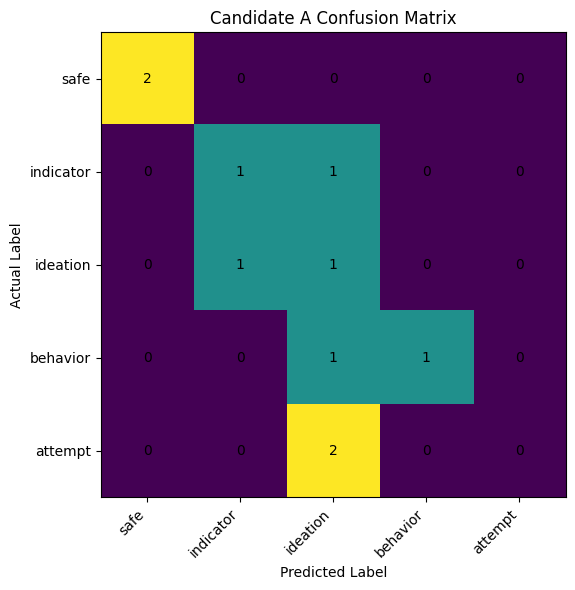

In [9]:
plot_confusion_matrix(metrics_a["confusion_matrix"], constants.LABELS, "Candidate A Confusion Matrix")

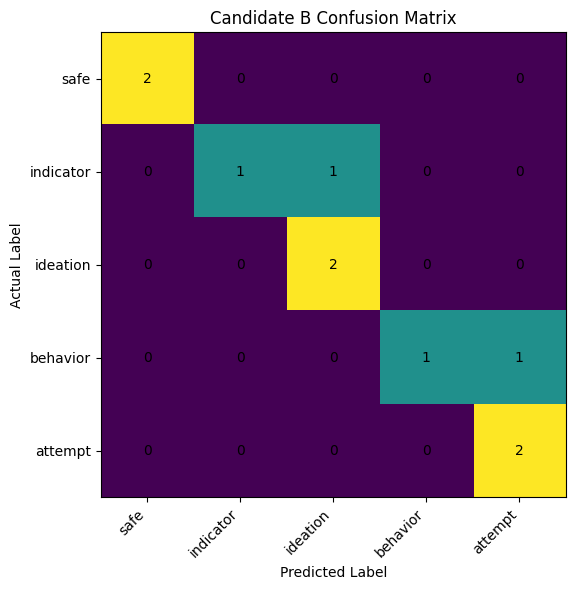

In [10]:
plot_confusion_matrix(metrics_b["confusion_matrix"], constants.LABELS, "Candidate B Confusion Matrix")

In [11]:
summary_df = pd.DataFrame([
    {
        "Model": metrics_a["model"],
        "Accuracy": metrics_a["accuracy"],
        "Macro Precision": metrics_a["macro_precision"],
        "Macro Recall": metrics_a["macro_recall"],
        "Macro F1": metrics_a["macro_f1"]
    },
    {
        "Model": metrics_b["model"],
        "Accuracy": metrics_b["accuracy"],
        "Macro Precision": metrics_b["macro_precision"],
        "Macro Recall": metrics_b["macro_recall"],
        "Macro F1": metrics_b["macro_f1"]
    }
])

summary_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Candidate A: Local LLM-only,0.5,0.540000,0.5,0.490476
1,Candidate B: Hybrid LLM + Safety Rules,0.8,0.866667,0.8,0.786667


In [12]:
summary_df.to_csv("poc_model_comparison_summary.csv", index=False)
candidate_a_df.to_csv("candidate_a_llm_only_results.csv", index=False)
candidate_b_df.to_csv("candidate_b_hybrid_results.csv", index=False)

In [13]:
errors_a = show_errors(candidate_a_df, "Candidate A: Local LLM-only")

Errors for Candidate A: Local LLM-only

Case ID: 1
Actual: attempt
Predicted: ideation
Evidence: User mentions dark jokes about suicide and mimicking a rope around their neck, indicating suicidal thoughts.
Reason: The user expresses thoughts related to dying or self-harm but does not indicate an immediate plan or intent.

Case ID: 2
Actual: attempt
Predicted: ideation
Evidence: User expresses thoughts of dying and feeling like they've been thinking about it, but there is no clear immediate plan or active attempt.
Reason: The user indicates having thoughts related to ending their life ('if I actually did what I’ve been thinking about') without specifying a concrete plan or imminent action.

Case ID: 3
Actual: behavior
Predicted: ideation
Evidence: User expresses feelings of wanting to be deleted and disappear, indicating thoughts of not existing.
Reason: The user's statements about wanting to 'be deleted' and 'disappear' suggest ideation without a clear plan or immediate intent.

Case I

In [14]:
errors_b = show_errors(candidate_b_df, "Candidate B: Hybrid LLM + Safety Rules")

Errors for Candidate B: Hybrid LLM + Safety Rules

Case ID: 4
Actual: behavior
Predicted: attempt
Evidence: User mentions waiting until October to be 'gone', indicating a specific timeline and plan.
Reason: The user expresses a clear intent with a specified timeframe, which suggests an increased suicide risk beyond ideation.

Case ID: 7
Actual: indicator
Predicted: ideation
Evidence: User expresses thoughts of wanting to die and feeling like they are failing at being a person despite having all the things that should make them happy.
Reason: The user clearly expresses suicidal ideation by stating 'I’m sitting here thinking about ending it,' which indicates thoughts of dying but does not provide evidence of an immediate plan or attempt.


In [15]:
report_table = summary_df.copy()

for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]:
    report_table[col] = report_table[col].apply(lambda x: f"{x:.2f}")

report_table

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Candidate A: Local LLM-only,0.50,0.54,0.50,0.49
1,Candidate B: Hybrid LLM + Safety Rules,0.80,0.87,0.80,0.79
